# Improving Student Academic Performance Through Data Analytics

## Exploratory Data Analysis (EDA)

This notebook explores the Student Performance Dataset to identify the factors influencing academic performance. The findings from this analysis will guide SQL analysis, KPI development, and the Power BI dashboard.

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib

## Section 2 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

## Section 3 — Load Dataset

In [2]:
df = pd.read_csv("../datasets/raw/Student_Performance_Dataset.csv")

In [3]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


## Section 4 — Dataset Overview

In [5]:
df.shape # number of rows and columns

(5000, 16)

In [6]:
df.columns # columns names

Index(['Student_ID', 'Age', 'Gender', 'Class', 'Study_Hours_Per_Day',
       'Attendance_Percentage', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Math_Score', 'Science_Score',
       'English_Score', 'Previous_Year_Score', 'Final_Percentage',
       'Performance_Level', 'Pass_Fail'],
      dtype='object')

In [7]:
df.isnull().sum() # # missing values

Student_ID                    0
Age                           0
Gender                        0
Class                         0
Study_Hours_Per_Day           0
Attendance_Percentage         0
Parental_Education            0
Internet_Access               0
Extracurricular_Activities    0
Math_Score                    0
Science_Score                 0
English_Score                 0
Previous_Year_Score           0
Final_Percentage              0
Performance_Level             0
Pass_Fail                     0
dtype: int64

In [8]:
df.duplicated().sum() # Checking for duplicate valuesa

np.int64(0)

## Section 5 — Descriptive Statistics

In [9]:
df.describe() # Describing the numerical columns

,Age,Class,Study_Hours_Per_Day,Attendance_Percentage,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,16.508800,10.496400,3.287260,74.919800,67.754800,66.895400,67.782800,67.282200,67.477656
std,1.718637,1.106812,1.587979,14.673842,18.724487,19.141195,19.248473,16.157511,10.964081
min,14.000000,9.000000,0.500000,50.000000,35.000000,35.000000,35.000000,40.000000,36.330000
25%,15.000000,10.000000,1.900000,62.000000,52.000000,50.000000,51.000000,53.000000,59.670000
50%,17.000000,10.000000,3.300000,75.000000,68.000000,67.000000,68.000000,67.000000,67.330000
75%,18.000000,11.000000,4.700000,88.000000,84.000000,83.000000,85.000000,81.000000,75.330000
max,19.000000,12.000000,6.000000,100.000000,100.000000,100.000000,100.000000,95.000000,98.330000


In [10]:
df.describe(include="object") ## Describing the categorical Columns

,Student_ID,Gender,Parental_Education,Internet_Access,Extracurricular_Activities,Performance_Level,Pass_Fail
count,5000,5000,5000,5000,5000,5000,5000
unique,5000,2,3,2,2,4,2
top,S0001,Female,Postgraduate,No,Yes,Good,Pass
freq,1,2553,1679,2622,2519,2191,4735


In [11]:
df['Parental_Education'].unique()

array(['Postgraduate', 'Graduate', 'High School'], dtype=object)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,16.508800,1.718637,14.00,15.00,17.00,18.00,19.00
Class,5000.0,10.496400,1.106812,9.00,10.00,10.00,11.00,12.00
Study_Hours_Per_Day,5000.0,3.287260,1.587979,0.50,1.90,3.30,4.70,6.00
Attendance_Percentage,5000.0,74.919800,14.673842,50.00,62.00,75.00,88.00,100.00
Math_Score,5000.0,67.754800,18.724487,35.00,52.00,68.00,84.00,100.00
Science_Score,5000.0,66.895400,19.141195,35.00,50.00,67.00,83.00,100.00
English_Score,5000.0,67.782800,19.248473,35.00,51.00,68.00,85.00,100.00
Previous_Year_Score,5000.0,67.282200,16.157511,40.00,53.00,67.00,81.00,95.00
Final_Percentage,5000.0,67.477656,10.964081,36.33,59.67,67.33,75.33,98.33


In [13]:
df.describe(include="object").T

,count,unique,top,freq
Student_ID,5000,5000,S0001,1
Gender,5000,2,Female,2553
Parental_Education,5000,3,Postgraduate,1679
Internet_Access,5000,2,No,2622
Extracurricular_Activities,5000,2,Yes,2519
Performance_Level,5000,4,Good,2191
Pass_Fail,5000,2,Pass,4735


In [14]:
df[df["Final_Percentage"] < 39.67][
    ["Student_ID", "Math_Score", "Science_Score", "English_Score",
     "Previous_Year_Score", "Final_Percentage"]
]

,Student_ID,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
1133,S1134,48,35,35,44,39.33
1278,S1279,37,36,44,78,39.00
1329,S1330,37,43,38,49,39.33
1684,S1685,39,36,40,46,38.33
1686,S1687,35,42,36,44,37.67
2108,S2109,39,43,36,93,39.33
2157,S2158,35,35,43,69,37.67
2572,S2573,37,43,36,76,38.67
2718,S2719,36,36,37,60,36.33
3090,S3091,44,36,35,91,38.33


In [15]:
df["Final_Percentage"].nsmallest(10)

2718    36.33
1686    37.67
2157    37.67
3190    37.67
1684    38.33
3090    38.33
2572    38.67
3409    38.67
1278    39.00
1133    39.33
Name: Final_Percentage, dtype: float64

In [16]:
df["Final_Percentage"].isna().sum()

np.int64(0)

In [17]:
df["Calculated_Final"] = (
    df["Math_Score"] +
    df["Science_Score"] +
    df["English_Score"]
) / 3

(df["Calculated_Final"] - df["Final_Percentage"]).abs().max()

0.003333333333337407

In [18]:
(df["Calculated_Final"].round(2) == df["Final_Percentage"]).all()


np.True_

In [19]:
(df["Calculated_Final"].round(2) - df["Final_Percentage"]).abs().max()

0.0

In [20]:
df.drop(columns="Calculated_Final", inplace=True)

In [21]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Class', 'Study_Hours_Per_Day',
       'Attendance_Percentage', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Math_Score', 'Science_Score',
       'English_Score', 'Previous_Year_Score', 'Final_Percentage',
       'Performance_Level', 'Pass_Fail'],
      dtype='object')

## Step 2: Create Our First EDA Visualization
📊 Visualization 1 — Final Percentage Distribution

Business Question

### How is overall academic performance distributed among the 5,000 students?

This is our first important EDA question because before investigating why students perform differently, we need to understand the overall performance pattern.
We'll use a histogram.

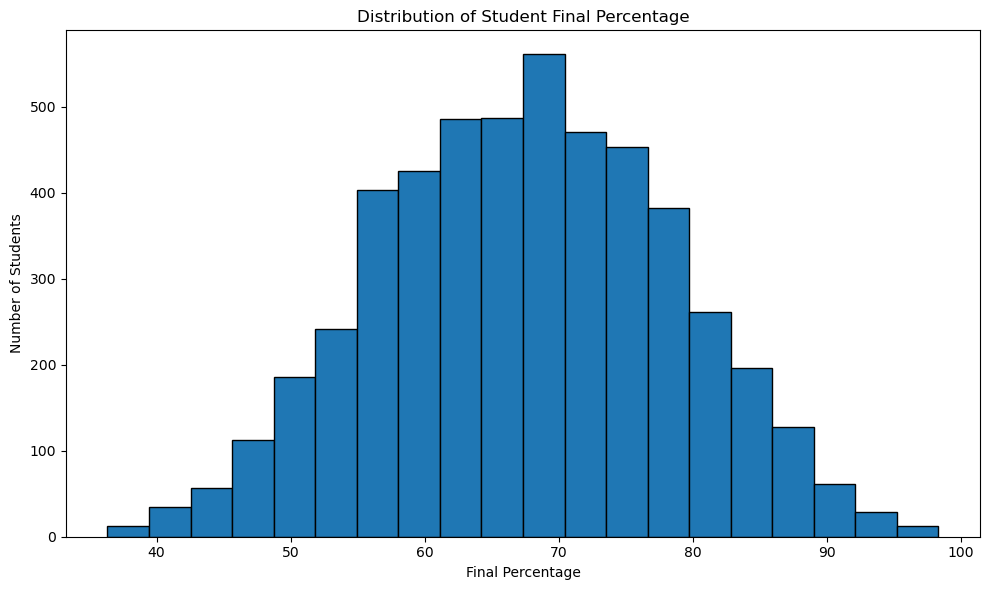

In [53]:
figsize = plt.figure(figsize=(10, 6))

figsize
plt.hist(
    df["Final_Percentage"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Student Final Percentage")
plt.xlabel("Final Percentage")
plt.ylabel("Number of Students")

plt.savefig(
    "../images/eda/final_percentage_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

### Interpretation

The distribution of students' final percentages is approximately bell-shaped and centered around the upper 60s and low 70s. The mean final percentage (67.48%) is very close to the median (67.33%), suggesting a relatively balanced distribution.

Student performance ranges from 36.33% to 98.33%, indicating substantial variation in academic outcomes. Most students are concentrated between approximately 55% and 80%, while relatively few students fall at the lower and upper extremes.

The distribution provides a useful baseline for investigating which academic and demographic factors are associated with differences in student performance.

In [23]:
df["Final_Percentage"].skew()

np.float64(-0.01839042947397884)

## Visualization 2:
### How much time do students spend studying each day?

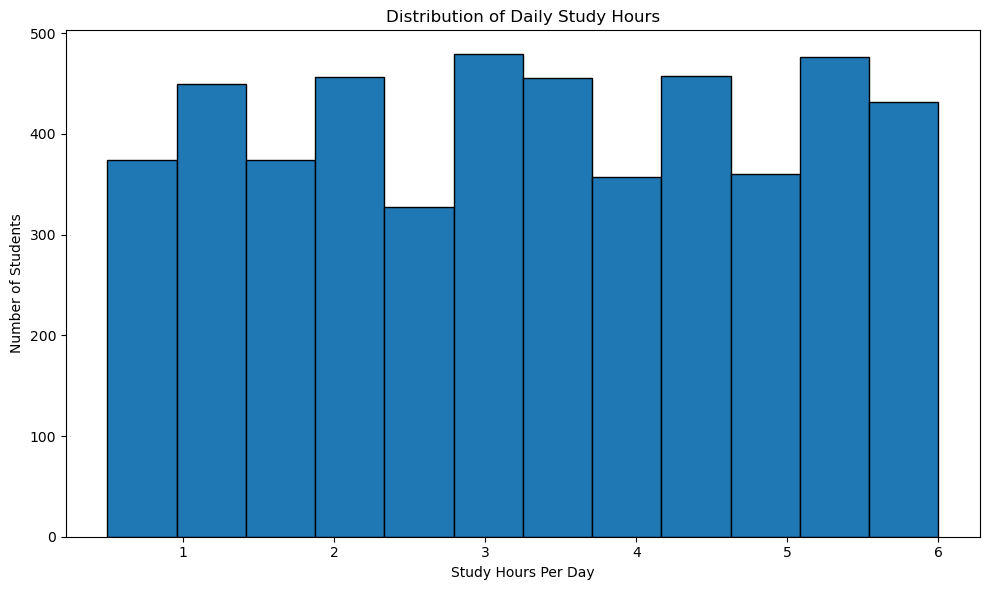

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Study_Hours_Per_Day"],
    bins=12,
    edgecolor="black"
)

plt.title("Distribution of Daily Study Hours")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Number of Students")

plt.savefig(
    "../images/eda/study_hours_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

### Interpretation

The distribution of daily study hours is relatively uniform across the observed range of 0.5 to 6 hours per day. No single study-hour interval dominates the distribution, indicating substantial variation in students' study habits.

The average study time is approximately 3.29 hours per day, with a median of 3.30 hours. The close agreement between the mean and median suggests that the variable is relatively balanced around its center.

This variation provides a useful basis for investigating whether increased study time is associated with improved academic performance.

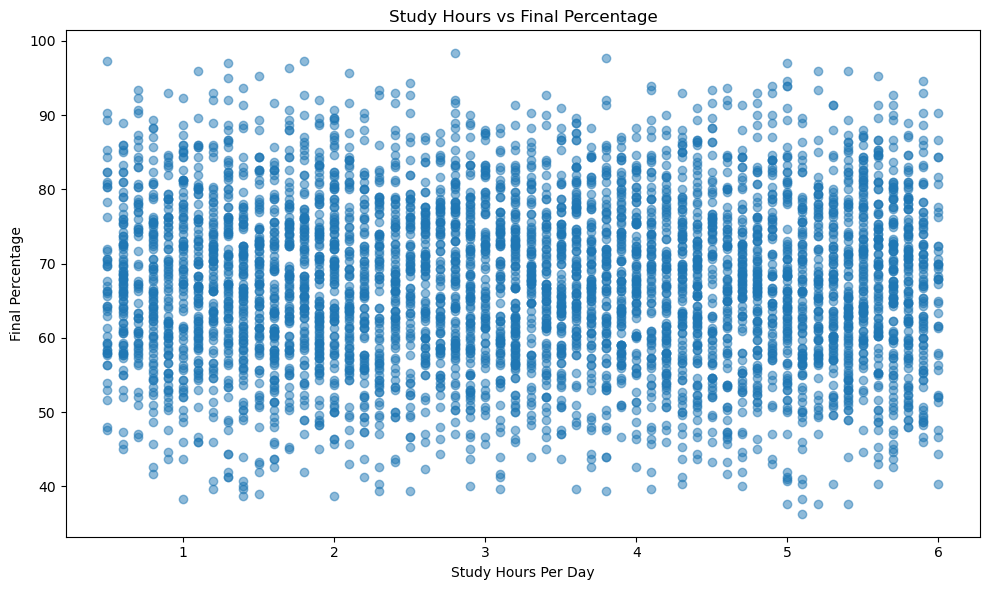

In [25]:
# Is more daily study time associated with better academic performance?

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Study_Hours_Per_Day"],
    df["Final_Percentage"],
    alpha=0.5
)

plt.title("Study Hours vs Final Percentage")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Final Percentage")

plt.tight_layout()
plt.show()

In [26]:
df["Study_Hours_Per_Day"].corr(df["Final_Percentage"])

np.float64(-0.01295760875428638)

### Interpretation

The scatter plot shows a broad distribution of final percentages across all levels of daily study hours, with no obvious upward or downward trend.

The Pearson correlation coefficient between Study_Hours_Per_Day and Final_Percentage is approximately -0.013, indicating a negligible linear relationship between the two variables.

Therefore, within this dataset, daily study time does not appear to be meaningfully associated with final academic performance. This finding should not be interpreted as evidence that study time has no effect on learning in general, but rather that this particular dataset does not show a meaningful linear association between the two variables.

The negligible relationship between reported study hours and final percentage warrants further investigation into the reliability of study-time reporting and other factors influencing academic performance. However, the available data does not provide sufficient evidence to attribute the pattern to examination malpractice.

Further analysis will examine other factors, including attendance and previous-year performance, to identify variables that may be more strongly associated with academic outcomes.

In [27]:
low_study_high_performance = df[
    (df["Study_Hours_Per_Day"] <= 1.5) &
    (df["Final_Percentage"] >= 85)
]

len(low_study_high_performance)

58

In [28]:
low_study_high_performance[
    [
        "Student_ID",
        "Study_Hours_Per_Day",
        "Attendance_Percentage",
        "Previous_Year_Score",
        "Math_Score",
        "Science_Score",
        "English_Score",
        "Final_Percentage"
    ]
].sort_values("Final_Percentage", ascending=False).head(20)

,Student_ID,Study_Hours_Per_Day,Attendance_Percentage,Previous_Year_Score,Math_Score,Science_Score,English_Score,Final_Percentage
3748,S3749,0.5,60,58,99,93,100,97.33
4244,S4245,1.3,57,42,95,96,100,97.00
4504,S4505,1.1,59,83,100,99,89,96.00
4454,S4455,1.5,56,42,99,95,92,95.33
1482,S1483,1.3,55,55,91,95,99,95.00
4854,S4855,1.4,73,44,98,98,85,93.67
1015,S1016,0.7,56,86,92,88,100,93.33
2661,S2662,0.9,57,51,84,99,96,93.00
1836,S1837,1.2,99,54,85,95,99,93.00
2668,S2669,1.0,86,40,99,94,84,92.33


In [29]:
print("Number of students:", len(low_study_high_performance))
print("Percentage of students:", 
      round(len(low_study_high_performance) / len(df) * 100, 2), "%")

Number of students: 58
Percentage of students: 1.16 %


In [30]:
df.groupby(
    df["Study_Hours_Per_Day"] <= 1.5
)["Final_Percentage"].agg(["count", "mean", "median"])

,count,mean,median
Study_Hours_Per_Day,,,
False,4083,67.433042,67.67
True,917,67.676303,67.33


### Low Study Hours and High Performance Analysis

An anomaly screening was performed to identify students who reported relatively low daily study time (≤1.5 hours) while achieving high final percentages (≥85%).

A total of 58 students met both criteria, representing 1.16% of the full dataset.

However, 917 students (18.34% of the dataset) reported studying 1.5 hours or less per day. Their average final percentage was 67.68%, compared with 67.43% among students studying more than 1.5 hours per day.

The difference in average performance is only approximately 0.24 percentage points. Therefore, low study time is not associated with substantially higher academic performance in this dataset.

The 58 students with low study hours and high performance may represent potentially unusual observations worthy of further investigation, but the available data does not provide sufficient evidence to attribute these patterns to examination malpractice.

In [1]:
attendance_corr = df["Attendance_Percentage"].corr(
    df["Final_Percentage"]
)

attendance_corr

NameError: name 'df' is not defined

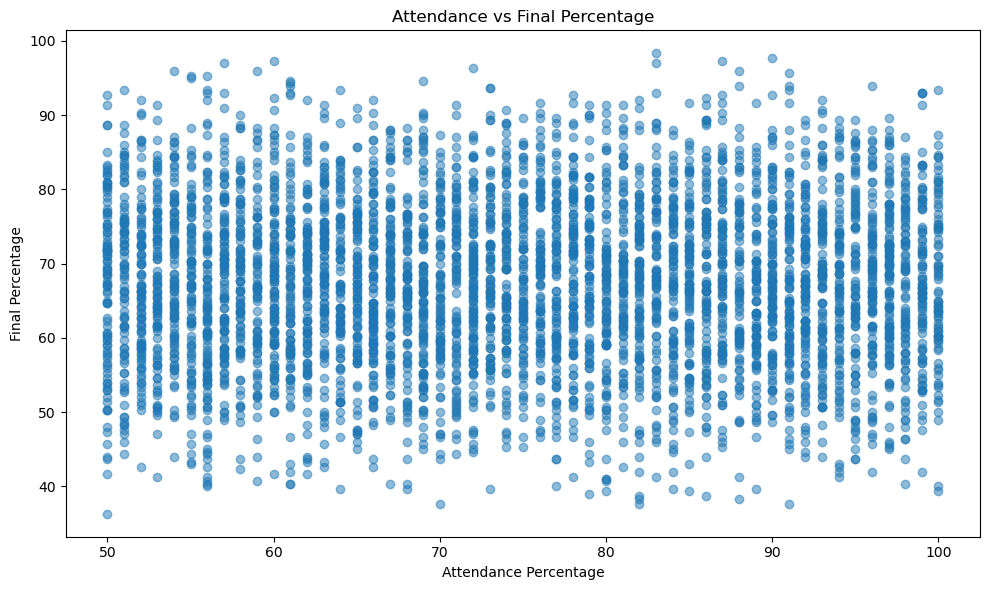

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Attendance_Percentage"],
    df["Final_Percentage"],
    alpha=0.5
)

plt.savefig(
    "../images/eda/attendance_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.title("Attendance vs Final Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Percentage")

plt.tight_layout()
plt.show()

### Attendance vs Final Percentage

The analysis examined the relationship between student attendance and final academic performance. The Pearson correlation coefficient was approximately 0.001, indicating an essentially negligible linear relationship between Attendance_Percentage and Final_Percentage.

This suggests that, within this dataset, differences in reported attendance are not meaningfully associated with differences in final academic performance.

However, this finding should not be interpreted as evidence that attendance has no effect on academic achievement in general. The result is specific to the available dataset and may be influenced by other factors, including the way attendance and performance were measured.

Further analysis will examine previous academic performance and other student characteristics to identify variables with stronger associations with current academic outcomes.

In [33]:
# Previous year Score correlation

previous_corr = df["Previous_Year_Score"].corr(
    df["Final_Percentage"]
)

previous_corr

np.float64(-0.01725209487564738)

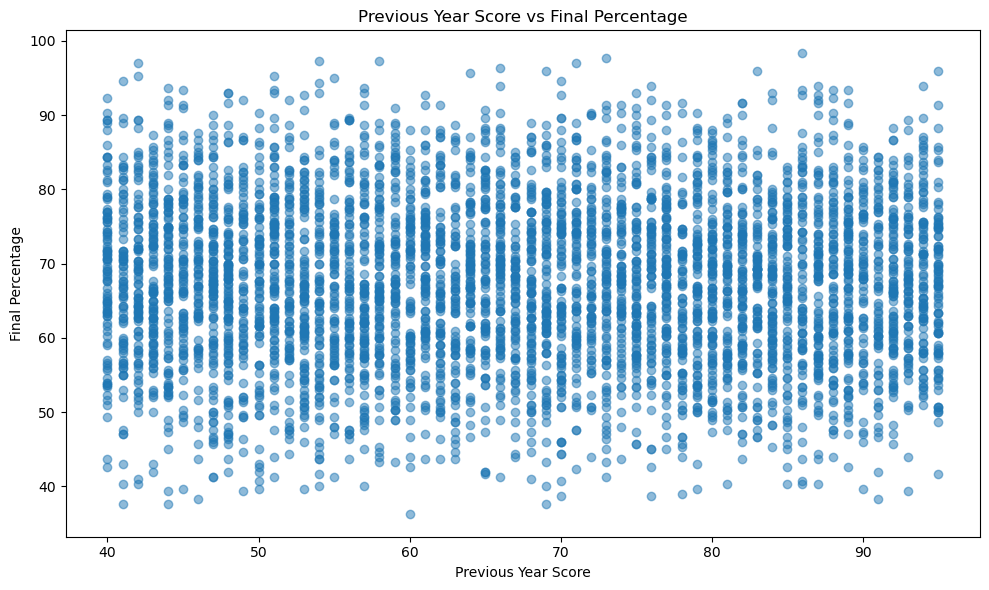

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Previous_Year_Score"],
    df["Final_Percentage"],
    alpha=0.5
)

plt.title("Previous Year Score vs Final Percentage")
plt.xlabel("Previous Year Score")
plt.ylabel("Final Percentage")

plt.tight_layout()
plt.show()

### Previous Year Score vs Final Percentage

The scatter plot shows a widely dispersed pattern with no clear upward or downward trend between Previous_Year_Score and Final_Percentage.

The Pearson correlation coefficient is approximately -0.017, indicating a negligible linear relationship between previous-year academic performance and current final performance in this dataset.

Therefore, previous-year score does not appear to be a meaningful linear predictor of current final percentage within the analyzed data. This finding is specific to this dataset and should not be generalized to student performance outside the dataset.

In [35]:
# Does average academic performance differ according to parental education level?
df.groupby("Parental_Education")["Final_Percentage"].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
Parental_Education,,,,
Graduate,1661,67.45,67.67,11.01
High School,1660,67.57,67.33,10.83
Postgraduate,1679,67.41,67.33,11.06


<Figure size 1000x600 with 0 Axes>

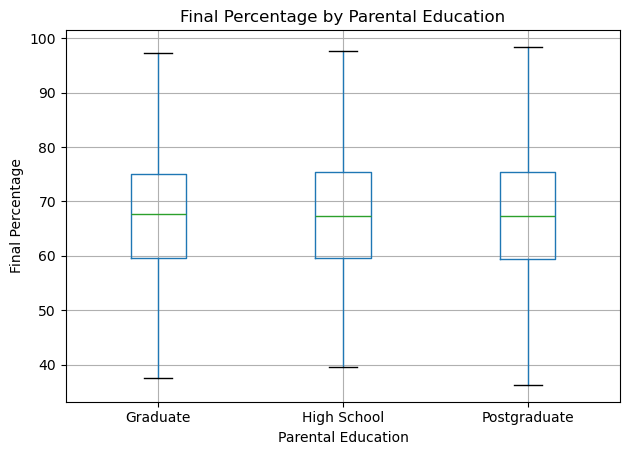

In [36]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="Final_Percentage",
    by="Parental_Education"
)

plt.title("Final Percentage by Parental Education")
plt.suptitle("")
plt.xlabel("Parental Education")
plt.ylabel("Final Percentage")

plt.tight_layout()
plt.show()

### Parental Education vs Final Percentage

The analysis examined whether student performance differs across parental education levels.

The average final percentages were very similar across all three groups: Graduate (67.45%), High School (67.57%), and Postgraduate (67.41%). The difference between the highest and lowest group means was only 0.16 percentage points.

The box plot also shows highly similar distributions, with comparable medians, interquartile ranges, and overall spread across the three groups.

Therefore, parental education level does not appear to be meaningfully associated with final academic performance in this dataset. This finding is specific to the analyzed dataset and should not be generalized beyond it.

In [41]:
# Does internet accessibility affect the overall percentage performance of students?

df.groupby('Internet_Access')['Final_Percentage'].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
Internet_Access,,,,
No,2622,67.53,67.50,10.93
Yes,2378,67.42,67.33,11.01


<Figure size 800x600 with 0 Axes>

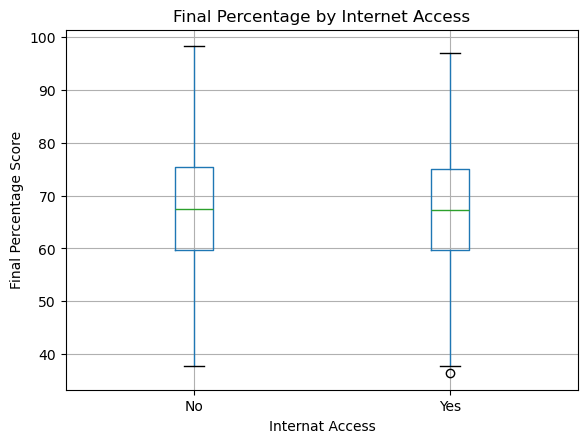

In [48]:
plt.figure(figsize=(8,6))

df.boxplot(
    column="Final_Percentage",
    by="Internet_Access",
)
plt.suptitle("")
plt.title("Final Percentage by Internet Access")
plt.xlabel("Internat Access")
plt.ylabel("Final Percentage Score")

plt.savefig(
    "../images/eda/internet-access.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Internet Access vs Final Percentage

The analysis examined whether students with internet access differed in academic performance from those without internet access.

Students without internet access had an average final percentage of 67.53%, while students with internet access had an average of 67.42%. The difference of only 0.11 percentage points is negligible.

The box plot also shows highly similar distributions between the two groups, with comparable medians, interquartile ranges, and overall spread.

Therefore, internet access does not appear to be meaningfully associated with final academic performance in this dataset. This finding is specific to the analyzed dataset and should not be generalized to other student populations.

In [49]:
# Do students who participate in extracurricular activities have different academic performance from those who do not?

df.groupby("Extracurricular_Activities")["Final_Percentage"].agg(
    ["count","mean","median", "std"]
).round(2)

,count,mean,median,std
Extracurricular_Activities,,,,
No,2481,67.17,67.33,10.91
Yes,2519,67.78,67.67,11.01


<Figure size 800x600 with 0 Axes>

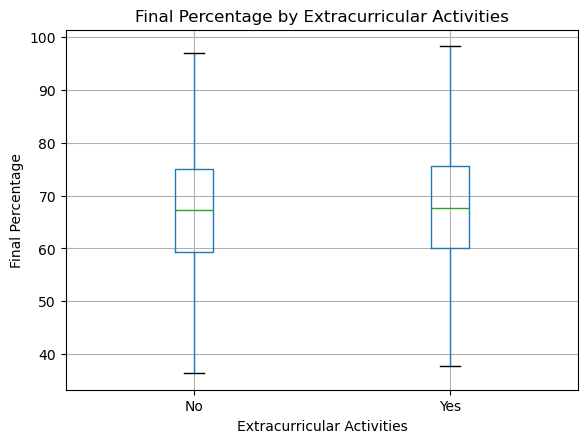

In [50]:
plt.figure(figsize=(8,6))

df.boxplot(
    column="Final_Percentage",
    by="Extracurricular_Activities"
)

plt.title("Final Percentage by Extracurricular Activities")
plt.suptitle("")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Final Percentage")

plt.savefig(
    "../images/eda/final_percentage_extracurricular.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Extracurricular Activities vs Final Percentage

The analysis examined whether participation in extracurricular activities was associated with differences in final academic performance.

Students who participated in extracurricular activities had an average final percentage of 67.78%, compared with 67.17% among students who did not participate. This represents a difference of approximately 0.61 percentage points.

The box plot shows highly similar distributions between the two groups, with comparable medians, interquartile ranges, and overall spread.

Although students involved in extracurricular activities had a slightly higher average performance, the difference is small relative to the overall variation in scores. Therefore, extracurricular participation does not appear to be a strong differentiating factor in final academic performance based on this descriptive analysis.

Further statistical testing would be required to determine whether the observed difference is statistically significant.

In [52]:
# Does final academic performance differ by gender in this dataset?

df.groupby("Gender")["Final_Percentage"].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
Gender,,,,
Female,2553,67.42,67.33,10.89
Male,2447,67.54,67.67,11.05


In [55]:
def figProperty(title, xlabel, ylabel, suptitle):
    return (plt.title(),
            plt.xlabel(),
            plt.ylabel(),
            plt.subtitle()
           )

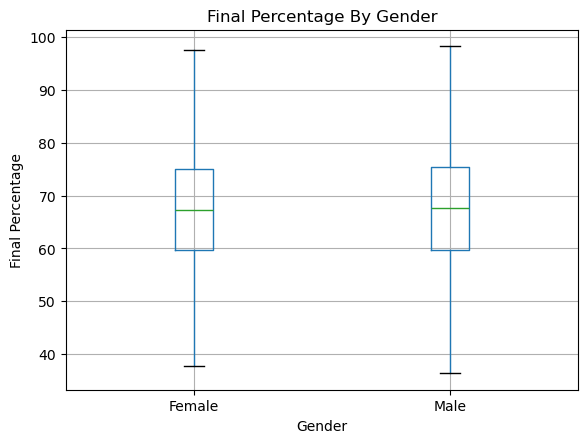

In [57]:
figsize

df.boxplot(
    column="Final_Percentage",
    by="Gender"
)
plt.title("Final Percentage By Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Final Percentage")

plt.show()

### Gender vs Final Percentage

The analysis examined whether final academic performance differs by gender.

Female students had an average final percentage of 67.42%, while male students had an average of 67.54%. The difference between the two groups was only 0.12 percentage points.

The box plot also shows highly similar distributions, with comparable medians, interquartile ranges, and overall spread.

Therefore, gender does not appear to be meaningfully associated with final academic performance in this dataset. This finding is specific to the analyzed dataset and should not be generalized beyond it.

In [58]:

df.groupby("Class")["Final_Percentage"].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
Class,,,,
9,1218,67.75,68.00,10.93
10,1301,67.51,67.67,10.76
11,1262,67.39,67.33,11.01
12,1219,67.27,67.00,11.17


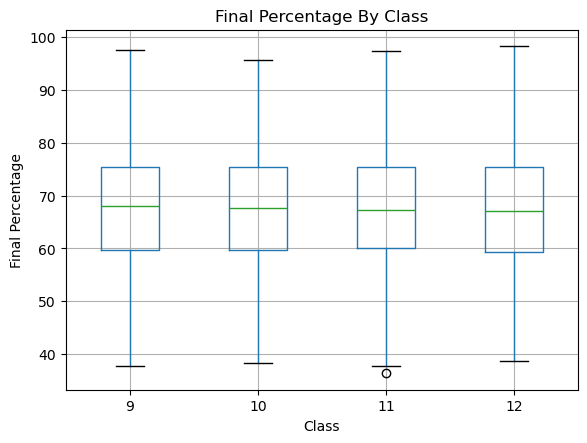

In [59]:
figsize

df.boxplot(
    column="Final_Percentage",
    by="Class"
)
plt.title("Final Percentage By Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Final Percentage")

plt.show()

In [60]:
class_11_outlier = df[
    (df["Class"] == 11) &
    (df["Final_Percentage"] < 38)
]

class_11_outlier[
    [
        "Student_ID",
        "Study_Hours_Per_Day",
        "Attendance_Percentage",
        "Previous_Year_Score",
        "Math_Score",
        "Science_Score",
        "English_Score",
        "Final_Percentage"
    ]
]

,Student_ID,Study_Hours_Per_Day,Attendance_Percentage,Previous_Year_Score,Math_Score,Science_Score,English_Score,Final_Percentage
1686,S1687,5.4,82,44,35,42,36,37.67
2718,S2719,5.1,50,60,36,36,37,36.33


### Class vs Final Percentage

The analysis examined whether final academic performance differs across Classes 9 to 12.

The box plots show broadly similar performance distributions across the four class levels. Class 11 contains two unusually low observations with final percentages of 37.67% and 36.33%. Investigation confirmed that these records are internally consistent with their Math, Science, and English scores and therefore represent legitimate low-performing students rather than data-quality errors.

The identified outliers were retained in the dataset because they represent valid observations.

Overall, Class level does not show a strong visual difference in final performance distributions based on the descriptive analysis.

# EDA: Subject-Level Analysis

In [64]:
subject_summary = df[
["Math_Score", "English_Score", "Science_Score"]
].agg(
    ["count","mean","median","std"]
).round(2)

subject_summary

,Math_Score,English_Score,Science_Score
count,5000.00,5000.00,5000.00
mean,67.75,67.78,66.90
median,68.00,68.00,67.00
std,18.72,19.25,19.14


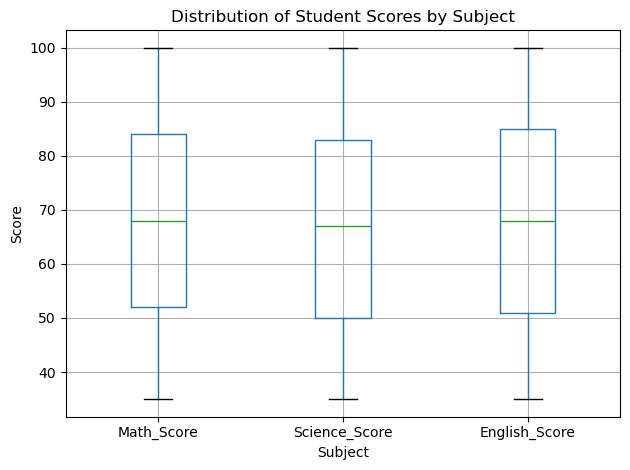

In [65]:
figsize

df[
    ["Math_Score", "Science_Score", "English_Score"]
].boxplot()

plt.title("Distribution of Student Scores by Subject")
plt.xlabel("Subject")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

### Subject-Level Performance Analysis

Descriptive statistics were calculated for Math, Science, and English scores.

English recorded the highest average score at 67.78%, followed closely by Mathematics at 67.75%. Science had the lowest average score at 66.90%. The difference between the highest and lowest subject averages was only 0.88 percentage points.

The median scores were also similar, with Math and English at 68% and Science at 67%.

English had the highest standard deviation (19.25), followed by Science (19.14) and Mathematics (18.72), indicating slightly greater variation in English performance. However, the differences in variability were relatively small.

Overall, the three subjects show broadly similar performance distributions, with no substantial difference in average scores across subjects.

In [66]:
subject_corr = df[
    ["Math_Score", "Science_Score", "English_Score"]
].corr()

subject_corr.round(3)

,Math_Score,Science_Score,English_Score
Math_Score,1.00,-0.020,0.010
Science_Score,-0.02,1.000,0.002
English_Score,0.01,0.002,1.000


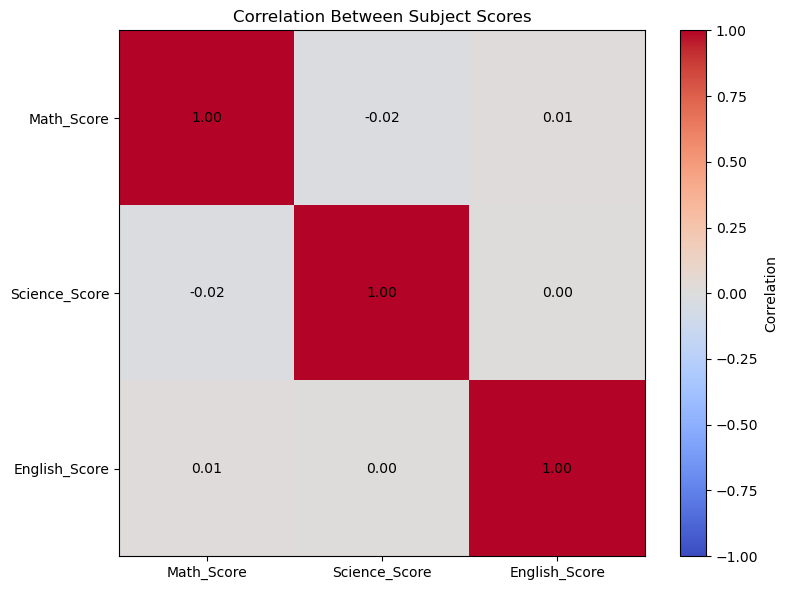

In [76]:
plt.figure(figsize=(8, 6))

plt.imshow(subject_corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(subject_corr.columns)),
    subject_corr.columns
)

plt.yticks(
    range(len(subject_corr.index)),
    subject_corr.index
)

for i in range(len(subject_corr.index)):
    for j in range(len(subject_corr.columns)):
        plt.text(
            j, i,
            f"{subject_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Subject Scores")
plt.tight_layout()
plt.show()

### Correlation Between Subject Scores

Pearson correlation was used to examine the linear relationships between Mathematics, Science, and English scores.

The results showed virtually no linear association between the three subjects:

- Math and Science: r = -0.020
- Math and English: r = 0.010
- Science and English: r = 0.002

All three correlations are extremely close to zero, indicating that performance in one subject does not appear to be a meaningful linear predictor of performance in another subject within this dataset.

This finding should be interpreted cautiously. Correlation measures linear association and does not establish the absence of non-linear relationships or causal relationships.

The unusually weak relationships between subject scores may also indicate that different factors influence performance across subjects, or that the dataset does not capture important variables affecting student achievement.

In [68]:
pass_fail_summary = df["Pass_Fail"].value_counts().to_frame("Count")

pass_fail_summary["Percentage"] = (
    pass_fail_summary["Count"] / len(df) * 100
).round(2)

pass_fail_summary

,Count,Percentage
Pass_Fail,,
Pass,4735,94.7
Fail,265,5.3


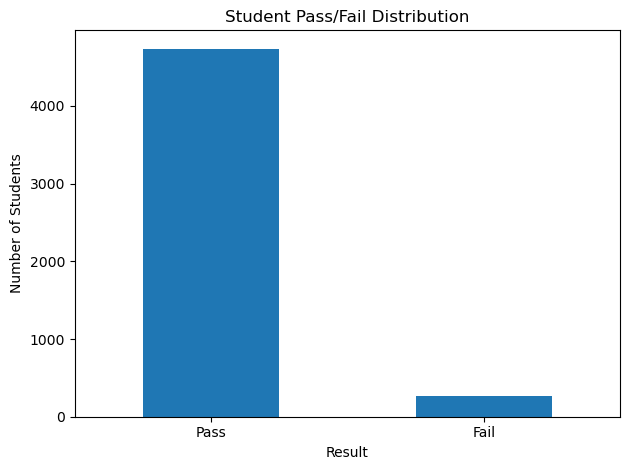

In [71]:
figsize

df["Pass_Fail"].value_counts().plot(kind="bar")

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.savefig(
    "../images/eda/pass-fail.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

In [72]:
df.groupby("Pass_Fail")["Final_Percentage"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
Pass_Fail,,,,,,
Fail,265,45.68,46.67,3.19,36.33,49.67
Pass,4735,68.70,68.33,9.91,50.00,98.33


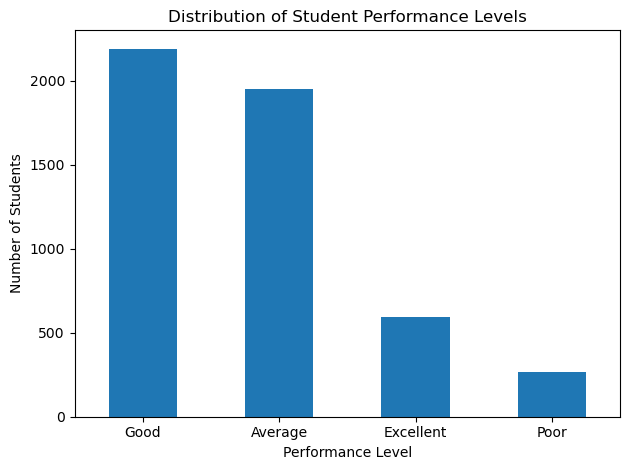

In [75]:
figsize

df["Performance_Level"].value_counts().plot(kind="bar")

plt.title("Distribution of Student Performance Levels")
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.savefig(
    "../images/eda/student-perfonamce-level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

# Overall EDA Findings

### Overall EDA Findings

The analysis found no strong linear relationship between final academic performance and the available demographic, engagement, and historical performance variables examined in this study.

Variables such as study hours, attendance, previous-year score, gender, parental education, internet access, extracurricular activities, and class showed either very weak correlations or only small differences in average final performance.

Therefore, the available dataset does not provide sufficient evidence to identify a single dominant driver of student success.

These findings should be interpreted within the limitations of the dataset. The absence of strong linear relationships does not necessarily mean that these factors have no influence on academic performance. Other factors not captured in the dataset—such as teaching quality, socioeconomic background, student motivation, learning environment, prior knowledge, and assessment conditions—may also contribute to student outcomes.

In [4]:
df["Pass_Fail"].value_counts()

Pass_Fail
Pass    4735
Fail     265
Name: count, dtype: int64